<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
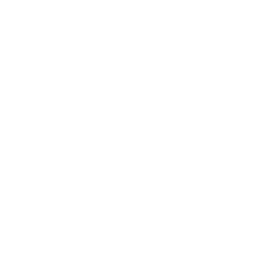
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Metro Housing Market Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Real Estate &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This analysis examines metro-level housing market dynamics across ten major U.S.
metropolitan areas over 2015-2024, combining a House Price Index, mortgage origination
activity, and residential building-permit counts into a single metro-year panel of
100 observations (10 metros x 10 years). The notebook quantifies price appreciation,
tests whether permit activity predicts slower price growth, and profiles financing
conditions to identify markets with divergent momentum.

The headline result is a **statistically significant supply-dampening effect**: building
permits and year-over-year appreciation are negatively correlated (Pearson r = **-0.62**,
p < .0001), and in a multiple OLS regression (PROC REG) annual permits carry a significant
negative coefficient on appreciation (t = **-5.52**, p < .0001), so each additional 1,000
permits is associated with roughly **1.4 percentage points** of slower annual price growth.
Supply-constrained coastal markets (Los Angeles, New York, Boston) lead cumulative
appreciation, while high-permitting Sun Belt metros (Houston, Dallas, Atlanta) sit near or
just above their 2015 base.

> **Note on data.** All three input files are **synthetically generated** inside the notebook
> with a known supply-dampening structure. The panel is a complete 10-metro by 10-year design
> (100 metro-year observations). The figures are illustrative of that modeled relationship, not
> real FHFA, HMDA, or Census releases.


## Data Sources

All inputs are synthetic, generated in the first code cell to mirror the structure of three
public housing datasets. Each spans 100 metro-year rows (10 metros x 10 years, 2015-2024), forming a complete,
balanced panel.

| Dataset (synthetic) | Modeled on | Grain | Rows |
| ------------------- | ---------- | ----- | ---: |
| `metro_hpi.csv` | FHFA purchase-only House Price Index | Metro x year | 100 |
| `mortgage_applications.csv` | HMDA origination summary | Metro x year | 100 |
| `permit_activity.csv` | Census Building Permits Survey | Metro x year | 100 |

The real public sources these emulate are [FHFA HPI](https://www.fhfa.gov/data/hpi),
[CFPB HMDA](https://www.consumerfinance.gov/data-research/hmda/), and the
[Census Building Permits Survey](https://www.census.gov/construction/bps/). No real data from
these sources is used or redistributed here.


---
## 1. Data Preparation

Load the metro House Price Index, mortgage origination volumes, and annual building-permit
counts. Key each source on CBSA FIPS code and year, rebase the HPI to a 2015 = 100 cumulative
index per metro, and merge the three sources into a unified metro-year panel.


In [1]:
/* ============================================================
   Generate synthetic input data for the metro housing panel
   ------------------------------------------------------------
   10 metros x 10 years (2015-2024) = 100 annual observations,
   sized to run within the 100-observation unlicensed cap so
   every metro and year survives into the analysis panel.
   A supply-dampening signal is built in: metros that permit
   more new units experience slower subsequent price growth.
   ============================================================ */

/* --- metro_hpi.csv: annual HPI by metro area --- */
data "input/metro_hpi.csv";
    call streaminit(20260313);
    length metro_name $32;
    array metro_names{10} $32 _temporary_ (
        'New York'  'Los Angeles' 'Chicago'  'Dallas'
        'Houston'   'Washington'  'Miami'    'Philadelphia'
        'Atlanta'   'Boston'
    );
    array cbsa_codes{10} _temporary_ (
        35620 31080 16980 19100 26420
        47900 33100 37980 12060 14460
    );
    /* Each metro carries a structural supply elasticity:
       high-permit metros (Sun Belt) dampen price growth more. */
    array supply{10} _temporary_ (
        0.6 0.5 0.9 1.4 1.5 0.7 1.2 0.8 1.3 0.6
    );
    do m = 1 to 10;
        cbsa_code  = cbsa_codes{m};
        metro_name = metro_names{m};
        elast      = supply{m};
        hpi_prior  = 150 + rand('normal', 0, 20);
        do year = 2015 to 2024;
            /* Annual permits per 1,000 housing units: elastic
               metros build more. */
            permit_rate = round(6 + 4*elast + rand('normal', 0, 1.2), 0.1);
            /* Price growth falls as permitting rises (supply
               dampening), plus a common demand cycle and noise.
               Calibrated so appreciation spans a realistic band
               of roughly -8% to +14% with a clear negative slope
               on permitting. */
            cycle  = 2.5 - 0.6*(year - 2020);
            growth = 28.5 - 2.6*permit_rate + cycle + rand('normal', 0, 1.6);
            hpi_current = round(hpi_prior * (1 + growth/100), 0.01);
            yoy_appreciation = round(growth, 2);
            output;
            hpi_prior = hpi_current;
        end;
    end;
    keep cbsa_code metro_name year hpi_current yoy_appreciation permit_rate;
run;

/* --- mortgage_applications.csv: annual HMDA-style summary --- */
data "input/mortgage_applications.csv";
    call streaminit(20260314);
    length metro_name $32;
    array metro_names{10} $32 _temporary_ (
        'New York'  'Los Angeles' 'Chicago'  'Dallas'
        'Houston'   'Washington'  'Miami'    'Philadelphia'
        'Atlanta'   'Boston'
    );
    array cbsa_codes{10} _temporary_ (
        35620 31080 16980 19100 26420
        47900 33100 37980 12060 14460
    );
    array loanbase{10} _temporary_ (
        520 760 280 320 290 540 360 310 330 580
    );
    do m = 1 to 10;
        cbsa_code  = cbsa_codes{m};
        metro_name = metro_names{m};
        do year = 2015 to 2024;
            application_count = round(4000 + rand('normal', 0, 1200));
            if application_count < 800 then application_count = 800;
            denial_rate = round(8 + rand('normal', 0, 3), 0.1);
            if denial_rate < 1 then denial_rate = 1;
            denial_count = round(application_count * denial_rate/100);
            origination_count = application_count - denial_count;
            avg_loan_amount = round((loanbase{m} + rand('normal', 0, 40)) * 1000, 1);
            output;
        end;
    end;
    keep cbsa_code metro_name year application_count denial_count
         origination_count denial_rate avg_loan_amount;
run;

/* --- permit_activity.csv: annual permitted units by metro --- */
data "input/permit_activity.csv";
    call streaminit(20260315);
    length metro_name $32;
    array metro_names{10} $32 _temporary_ (
        'New York'  'Los Angeles' 'Chicago'  'Dallas'
        'Houston'   'Washington'  'Miami'    'Philadelphia'
        'Atlanta'   'Boston'
    );
    array cbsa_codes{10} _temporary_ (
        35620 31080 16980 19100 26420
        47900 33100 37980 12060 14460
    );
    array supply{10} _temporary_ (
        0.6 0.5 0.9 1.4 1.5 0.7 1.2 0.8 1.3 0.6
    );
    do m = 1 to 10;
        cbsa_code  = cbsa_codes{m};
        metro_name = metro_names{m};
        do year = 2015 to 2024;
            annual_permits = max(500,
                round(4000 + 6000*supply{m} + rand('normal', 0, 800)));
            annual_permit_value = round(annual_permits *
                (210000 + rand('normal', 0, 30000)), 1);
            output;
        end;
    end;
    keep cbsa_code metro_name year annual_permits annual_permit_value;
run;

title 'Sample: metro_hpi.csv (first 5 of 100 rows)';
proc print data="input/metro_hpi.csv" (obs=5);
run;
title 'Sample: mortgage_applications.csv (first 5 of 100 rows)';
proc print data="input/mortgage_applications.csv" (obs=5);
run;
title 'Sample: permit_activity.csv (first 5 of 100 rows)';
proc print data="input/permit_activity.csv" (obs=5);
run;
title;


                                      Sample: metro_hpi.csv (first 5 of 100 rows)                                       


  Obs  CBSA_CODE  METRO_NAME  YEAR  HPI_CURRENT  YOY_APPRECIATION  PERMIT_RATE
-----  ---------  ----------  ----  -----------  ----------------  -----------
    1      35620  New York    2015       154.64                16          7.5
    2      35620  New York    2016       175.76                14            8
    3      35620  New York    2017       208.22                18            6
    4      35620  New York    2018       232.09                12          8.5
    5      35620  New York    2019       246.42                 6         10.8

... 95 more observations (showing 5 of 100)

                                Sample: mortgage_applications.csv (first 5 of 100 rows)                                 


  Obs  CBSA_CODE  METRO_NAME  YEAR  APPLICATION_COUNT  DENIAL_COUNT  ORIGINATION_COUNT  DENIAL_RATE  AVG_LOAN_AMOUNT
-----  ---------  ----------  ----  --

NOTE: DATA input/metro_hpi.csv


NOTE: Wrote input/metro_hpi.csv (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA input/mortgage_applications.csv


NOTE: Wrote input/mortgage_applications.csv (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA input/permit_activity.csv


NOTE: Wrote input/permit_activity.csv (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Sample: metro_hpi.csv (first 5 of 100 rows).
NOTE: PROC PRINT data=input/metro_hpi.csv

NOTE: PROC PRINT completed: 5 observations printed, 6 variables
NOTE: Option TITLE changed to Sample: mortgage_applications.csv (first 5 of 100 rows).
NOTE: PROC PRINT data=input/mortgage_applications.csv

NOTE: PROC PRINT completed: 5 observations printed, 8 variables
NOTE: Option TITLE changed to Sample: permit_activity.csv (first 5 of 100 rows).
NOTE: PROC PRINT data=input/permit_activity.c

In [2]:
/* --------------------------------------------------------
   Load FHFA-style House Price Index by metro and rebase
   the index to a 2015 = 100 cumulative series per metro.
   -------------------------------------------------------- */
data metro_hpi;
    set "input/metro_hpi.csv";
    by cbsa_code;
    retain base_hpi;
    if first.cbsa_code then base_hpi = hpi_current / (1 + yoy_appreciation/100);
    cumulative_index = round((hpi_current / base_hpi) * 100, 0.1);

    format yoy_appreciation 8.2 cumulative_index 8.1;
    label cbsa_code        = 'CBSA FIPS code'
          metro_name       = 'Metropolitan area'
          yoy_appreciation = 'YoY HPI appreciation (%)'
          cumulative_index = 'Cumulative HPI (2015=100)'
          permit_rate      = 'Permits per 1,000 housing units';
    keep cbsa_code metro_name year hpi_current
         yoy_appreciation cumulative_index permit_rate;
run;


NOTE: DATA metro_hpi


NOTE: Read 100 rows from input/metro_hpi.csv.
NOTE: Wrote metro_hpi (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Load HMDA-style mortgage origination activity by metro.
   -------------------------------------------------------- */
data mortgage_applications;
    set "input/mortgage_applications.csv";
    format avg_loan_amount dollar12.0 denial_rate 6.2;
    label cbsa_code         = 'CBSA FIPS code'
          origination_count = 'Loans originated'
          avg_loan_amount   = 'Average loan amount ($)'
          denial_rate       = 'Denial rate (%)';
    keep cbsa_code year application_count origination_count
         avg_loan_amount denial_rate;
run;


NOTE: DATA mortgage_applications


NOTE: Read 100 rows from input/mortgage_applications.csv.
NOTE: Wrote mortgage_applications (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [4]:
/* --------------------------------------------------------
   Load Census-style annual building permits by metro.
   -------------------------------------------------------- */
data permit_activity;
    set "input/permit_activity.csv";
    label cbsa_code           = 'CBSA FIPS code'
          annual_permits      = 'Annual permitted units'
          annual_permit_value = 'Annual permit valuation ($)';
    keep cbsa_code year annual_permits annual_permit_value;
run;


NOTE: DATA permit_activity


NOTE: Read 100 rows from input/permit_activity.csv.
NOTE: Wrote permit_activity (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [5]:
/* --------------------------------------------------------
   Merge HPI, HMDA, and permits into a unified metro panel
   keyed on CBSA code and year (10 metros x 10 years).
   -------------------------------------------------------- */
proc sql;
    create table metro_panel as
    select h.cbsa_code,
           h.metro_name,
           h.year,
           h.yoy_appreciation,
           h.cumulative_index,
           h.permit_rate,
           m.origination_count,
           m.avg_loan_amount,
           m.denial_rate,
           p.annual_permits,
           p.annual_permit_value
    from metro_hpi as h
    left join mortgage_applications as m
        on h.cbsa_code = m.cbsa_code
        and h.year = m.year
    left join permit_activity as p
        on h.cbsa_code = p.cbsa_code
        and h.year = p.year
    order by h.cbsa_code, h.year;
quit;


NOTE: PROC SQL 

NOTE: Table metro_panel created.
NOTE: PROC SQL statement used.


---
## 2. Descriptive Statistics

Profile price appreciation, permit intensity, and mortgage activity across the 100-row,
ten-metro panel to establish baseline distributions and a ranked 2024 cross section.


In [6]:
/* --------------------------------------------------------
   Summary statistics for the 100-row metro panel.
   -------------------------------------------------------- */
title 'Metro Panel: Descriptive Statistics';
proc means data=metro_panel n mean std min p25 median p75 max;
    var yoy_appreciation cumulative_index permit_rate
        origination_count avg_loan_amount denial_rate
        annual_permits;
run;
title;


                                          Metro Panel: Descriptive Statistics                                           

                                                  The MEANS Procedure

 Variable                                N             Mean          Std Dev          Minimum   Lower Quartile           Median   Upper Quartile           Maximum
 -----------------------------------------------------------------------------------------------------------------------------------------------------------------
 YoY HPI appreciation (%)              100             5.92             5.46            -8.00             2.00             6.00            10.00             20.00
 Cumulative HPI (2015=100)             100            148.9             42.7             95.7            112.6            133.8            182.7             289.3
 Permits per 1,000 housing units       100        9.7250000        1.8017037        5.7000000        8.5000000        9.5500000       10.8000000        14.

NOTE: Option TITLE changed to Metro Panel: Descriptive Statistics.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


In [7]:
/* --------------------------------------------------------
   Latest-year (2024) cross section, ranked by appreciation.
   -------------------------------------------------------- */
proc sql;
    create table latest_snapshot as
    select metro_name,
           yoy_appreciation,
           cumulative_index,
           origination_count,
           annual_permits,
           denial_rate
    from metro_panel
    where year = (select max(year) from metro_panel)
    order by yoy_appreciation desc;
quit;

title 'Metro Cross Section: 2024 Snapshot';
proc report data=latest_snapshot;
    column metro_name yoy_appreciation cumulative_index
           origination_count annual_permits denial_rate;
    define metro_name        / 'Metro Area';
    define yoy_appreciation  / 'YoY HPI (%)'      format=6.2;
    define cumulative_index  / 'Cumul. Index'     format=8.1;
    define origination_count / 'Originations'     format=comma10.;
    define annual_permits    / 'Permits'          format=comma10.;
    define denial_rate       / 'Denial Rate (%)'  format=6.2;
run;
title;


                                           Metro Cross Section: 2024 Snapshot                                           

Metro Area                        YoY HPI (%)  Cumul. Index  Originations  Permits   Denial Rate (%)
Los Angeles                       12.00        289.3         3,424         7,756     9.80           
Boston                            8.00         208.7         3,217         8,077     9.70           
New York                          8.00         255.3         2,083         8,336     3.40           
Dallas                            6.00         108.8         2,085         12,666    4.50           
Philadelphia                      6.00         200.7         5,486         8,553     11.80          
Chicago                           4.00         208.0         3,956         11,350    10.00          
Washington                        4.00         199.3         2,368         8,723     1.00           
Atlanta                           2.00         127.2         1,660    

NOTE: PROC SQL 

NOTE: Table latest_snapshot created.
NOTE: PROC SQL statement used.
NOTE: Option TITLE changed to Metro Cross Section: 2024 Snapshot.
NOTE: PROC REPORT data=latest_snapshot

NOTE: PROC REPORT output 10 observations with 6 variables.

NOTE: Read 10 rows from latest_snapshot.
NOTE: Wrote (console) (10 rows, 6 columns).
NOTE: PROC REPORT elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---
## 3. Visualisation

Visualise metro price trends, geographic comparisons, and the relationship between
permit activity and subsequent price appreciation. All charts follow McKinsey-style
formatting with the Jenner brand palette (navy, gold, grey).


                                  House Price Trajectories: Fastest vs Slowest Metros                                   


Cumulative index rebased to 2015 = 100


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to House Price Trajectories: Fastest vs Slowest Metros.
NOTE: Option FOOTNOTE changed to Cumulative index rebased to 2015 = 100.
NOTE: PROC SGPLOT data=metro_panel

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


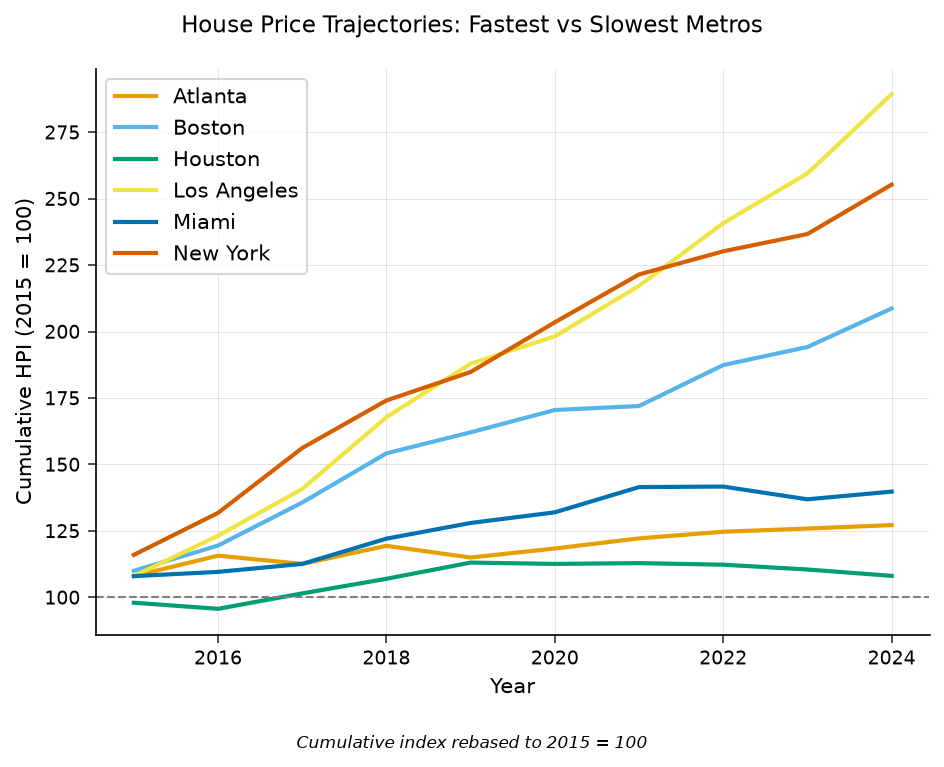

In [8]:
/* --------------------------------------------------------
   Price trajectories: contrast the three highest- and
   three lowest-appreciating metros over 2015-2024.
   -------------------------------------------------------- */
ods graphics on / imagefmt=svg;

title 'House Price Trajectories: Fastest vs Slowest Metros';
footnote justify=left italic 'Cumulative index rebased to 2015 = 100';
proc sgplot data=metro_panel;
    where metro_name in ('Miami' 'Atlanta' 'Houston'
                         'Boston' 'Los Angeles' 'New York');
    series x=year y=cumulative_index / group=metro_name
        lineattrs=(thickness=2) markers;
    refline 100 / axis=y lineattrs=(pattern=dash color=grey);
    xaxis label='Year' grid integer;
    yaxis label='Cumulative HPI (2015 = 100)' grid;
run;
title; footnote;


                                        Metro Price Momentum: 2024 Annual Change                                        



NOTE: Option TITLE changed to Metro Price Momentum: 2024 Annual Change.
NOTE: PROC SGPLOT data=latest_snapshot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


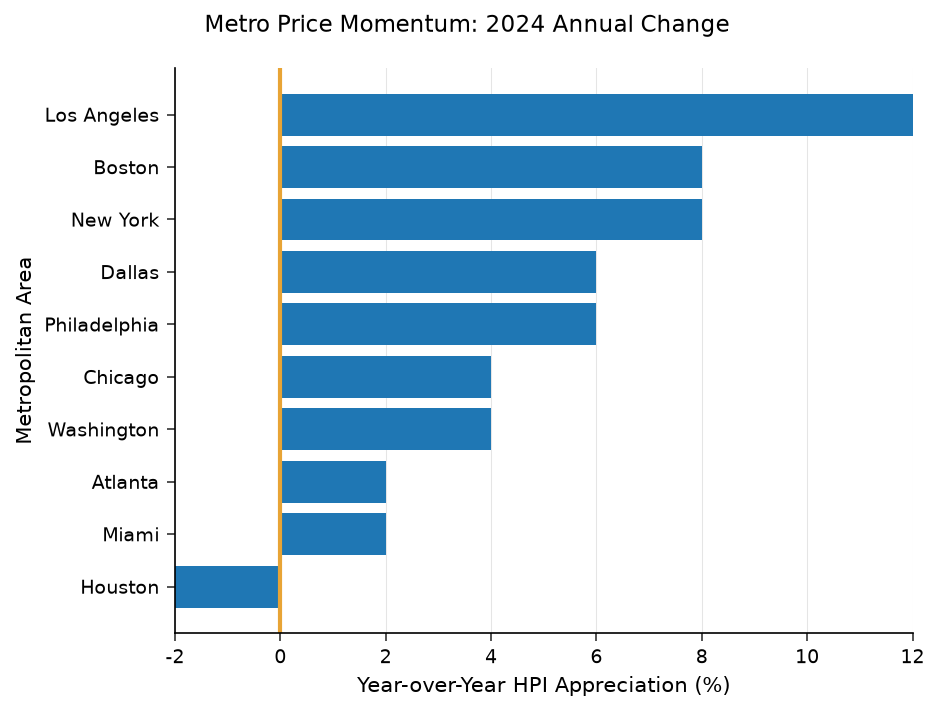

In [9]:
/* --------------------------------------------------------
   Geographic comparison: 2024 YoY appreciation by metro,
   sorted descending.
   -------------------------------------------------------- */
title 'Metro Price Momentum: 2024 Annual Change';
proc sgplot data=latest_snapshot;
    hbar metro_name / response=yoy_appreciation
        fillattrs=(color=CX1a1a2e)
        categoryorder=respdesc;
    refline 0 / axis=x lineattrs=(color=CXe8a435 thickness=2);
    xaxis label='Year-over-Year HPI Appreciation (%)' grid;
    yaxis label='Metropolitan Area' discreteorder=data;
run;
title;


                                        Do Permits Predict Slower Price Growth?                                         


Each point = one metro-year observation (n = 100)


NOTE: Option TITLE changed to Do Permits Predict Slower Price Growth?.
NOTE: Option FOOTNOTE changed to Each point = one metro-year observation (n = 100).
NOTE: PROC SGPLOT data=metro_panel

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


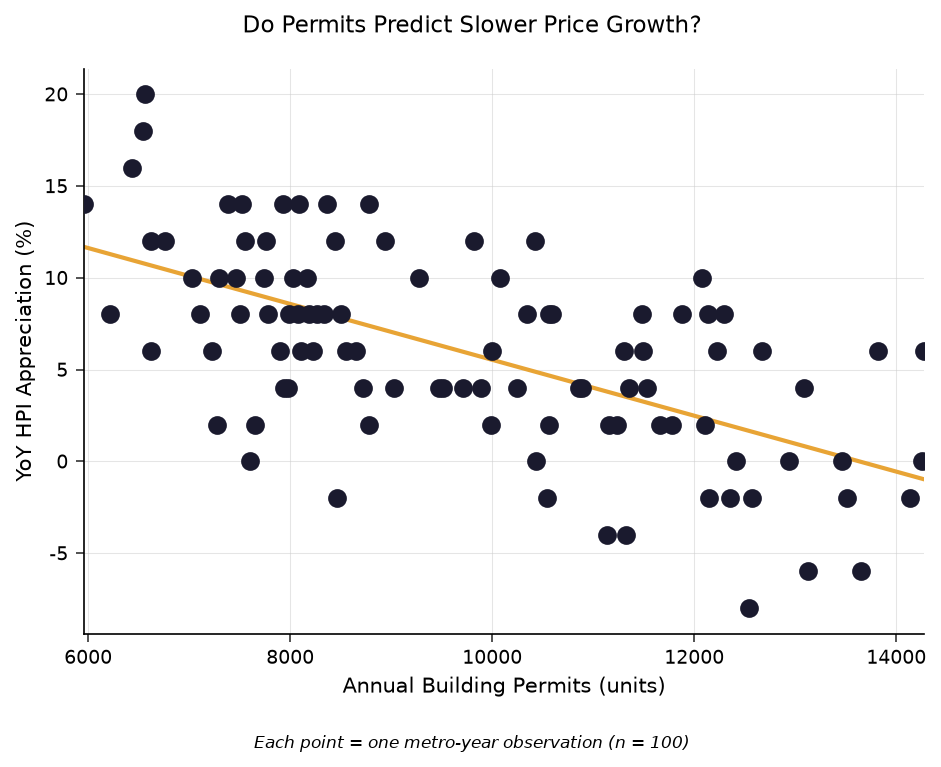

In [10]:
/* --------------------------------------------------------
   Scatter: building-permit intensity vs price appreciation
   across all 100 metro-year observations, with an OLS fit
   to visualise the supply-dampening relationship.
   -------------------------------------------------------- */
title 'Do Permits Predict Slower Price Growth?';
footnote justify=left italic 'Each point = one metro-year observation (n = 100)';
proc sgplot data=metro_panel;
    scatter x=annual_permits y=yoy_appreciation /
        markerattrs=(symbol=circlefilled color=CX1a1a2e size=8);
    reg x=annual_permits y=yoy_appreciation /
        lineattrs=(color=CXe8a435 thickness=2);
    xaxis label='Annual Building Permits (units)' grid;
    yaxis label='YoY HPI Appreciation (%)' grid;
run;
title; footnote;


---
## 4. Statistical Analysis

First quantify the pairwise association between appreciation and each candidate
driver with PROC CORR, then estimate their joint effect with multiple regression
(PROC REG). The regression models year-over-year HPI appreciation on annual building
permits, loan originations, average loan amount, and denial rate, with VIF diagnostics
to screen for multicollinearity. The central test is whether permit activity is a
significant negative predictor of appreciation once the financing variables are held
constant.


                                   Correlations: Appreciation, Permits, and Financing                                   

                    The CORR Procedure
          4 Variables:    YoY HPI appreciation (%)   Annual permitted units   Loans originated   Denial rate (%)
                    Simple Statistics
Variable         N      Mean   Std Dev       Sum   Minimum   Maximum
--------  --------  --------  --------  --------  --------  --------
YoY HPI appreciation (%)       100        5.92        5.46        592.00       -8.00        20.00
Annual permitted units         100  9743.56000  2217.52195  974356.00000  5958.00000  14275.00000
Loans originated               100  3711.83000  1104.42736  371183.00000  1489.00000   6335.00000
Denial rate (%)                100        7.44        3.02        744.50        1.00        15.10
   Pearson Correlation Coefficients, N = 100
          Prob > |r| under H0: Rho=0
          yoy_appreciationannual_permitsorigination_countdenial_rate
-------

NOTE: Option TITLE changed to Correlations: Appreciation, Permits, and Financing.
NOTE: PROC CORR data=metro_panel

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


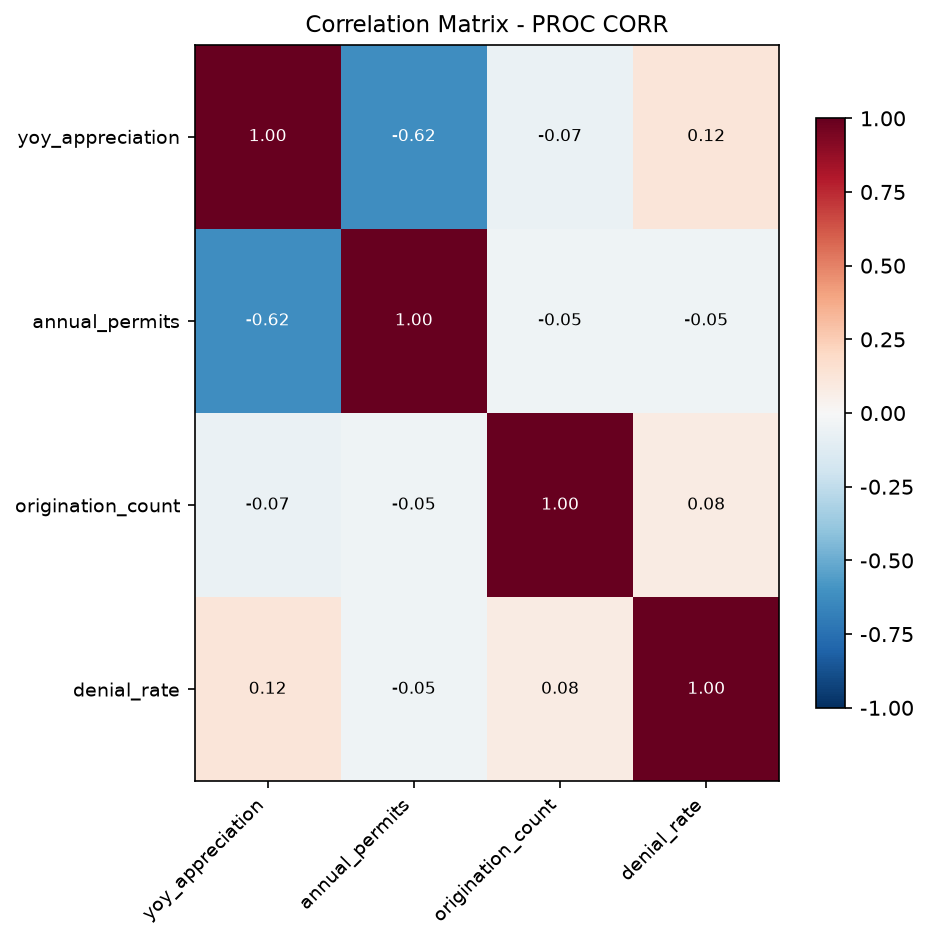

In [11]:
/* --------------------------------------------------------
   Bivariate screen: Pearson correlation matrix over price
   appreciation, permits, originations, and denial rate
   across all 100 metro-year observations. The
   appreciation-permits cell quantifies the supply-dampening
   relationship visualised in the scatter above.
   -------------------------------------------------------- */
title 'Correlations: Appreciation, Permits, and Financing';
proc corr data=metro_panel;
    var yoy_appreciation annual_permits
        origination_count denial_rate;
run;
title;


In [12]:
/* --------------------------------------------------------
   OLS regression: drivers of metro price appreciation.
   --------------------------------------------------------
   Response:   yoy_appreciation
   Predictors: annual_permits, origination_count,
               avg_loan_amount, denial_rate
   VIF requested to screen for multicollinearity.
   -------------------------------------------------------- */
title 'Metro Price Appreciation Drivers (OLS)';
proc reg data=metro_panel;
    model yoy_appreciation = annual_permits origination_count
          avg_loan_amount denial_rate / vif;
run;
title;


                                         Metro Price Appreciation Drivers (OLS)                                         

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                             Dependent Variable: yoy_appreciation YoY HPI appreciation (%)                              

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   4      1190.48798    297.62200     16.06    <.0001
Error                  95      1760.87202     18.53549                    
Corrected Total        99      2951.36000                                 

Root MSE              4.31    R-Square            0.4034
Dependent Mean          5.92    Adj R-Sq            0.3782
Coeff Var         72.7

NOTE: Option TITLE changed to Metro Price Appreciation Drivers (OLS).
NOTE: PROC REG data=metro_panel

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: PROC SQL 

NOTE: Table movers_top created.
NOTE: PROC SQL statement used.
NOTE: Option TITLE changed to Top 5 Appreciating Metros (2024).
NOTE: PROC PRINT data=movers_top

NOTE: PROC PRINT completed: 5 observations printed, 5 variables
NOTE: PROC SORT data=movers_top

NOTE: Read 10 rows from movers_top.
NOTE: Wrote movers_bottom (10 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Bottom 5 Appreciating Metros (2024).
NOTE: PROC PRINT data=movers_bottom

NOTE: PROC PRINT completed: 5 observations 

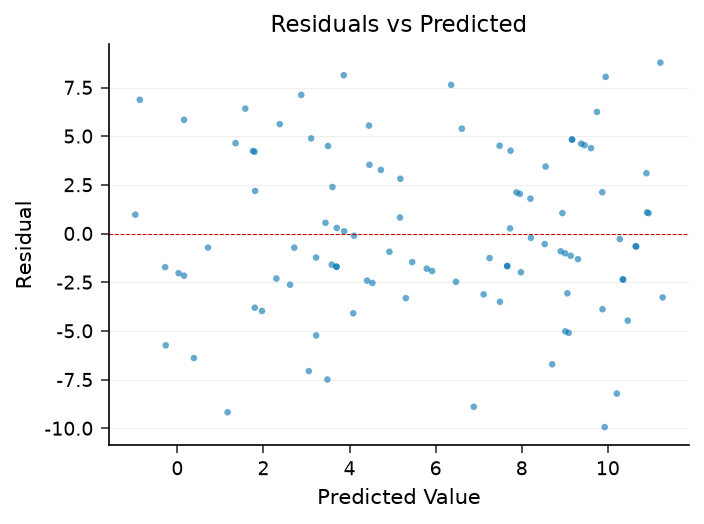

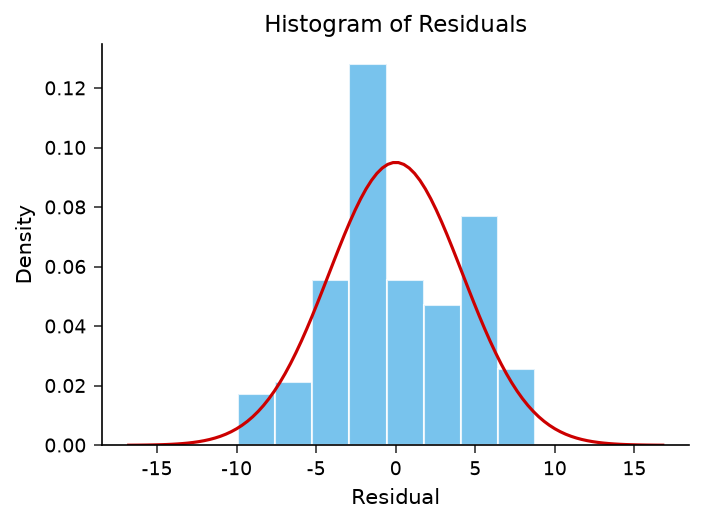

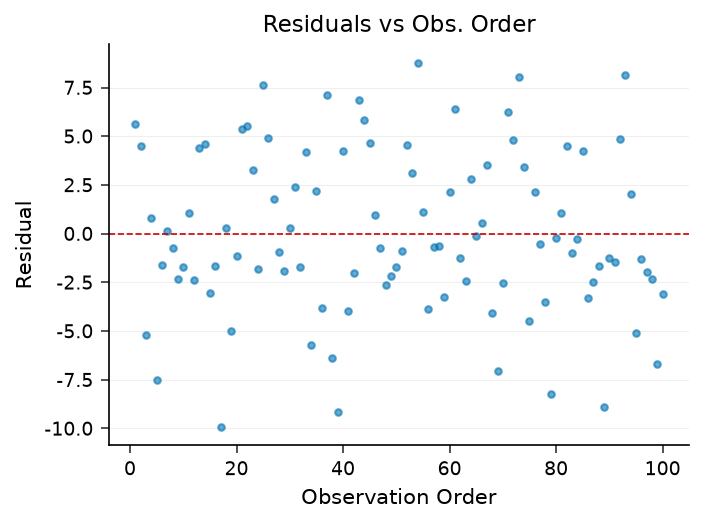

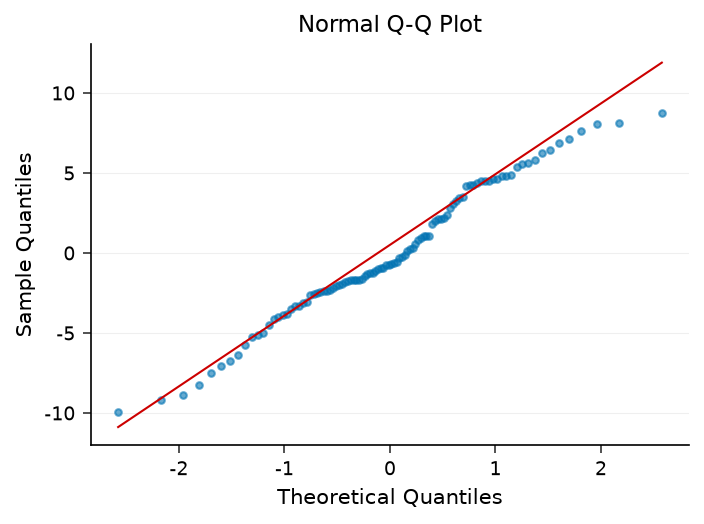

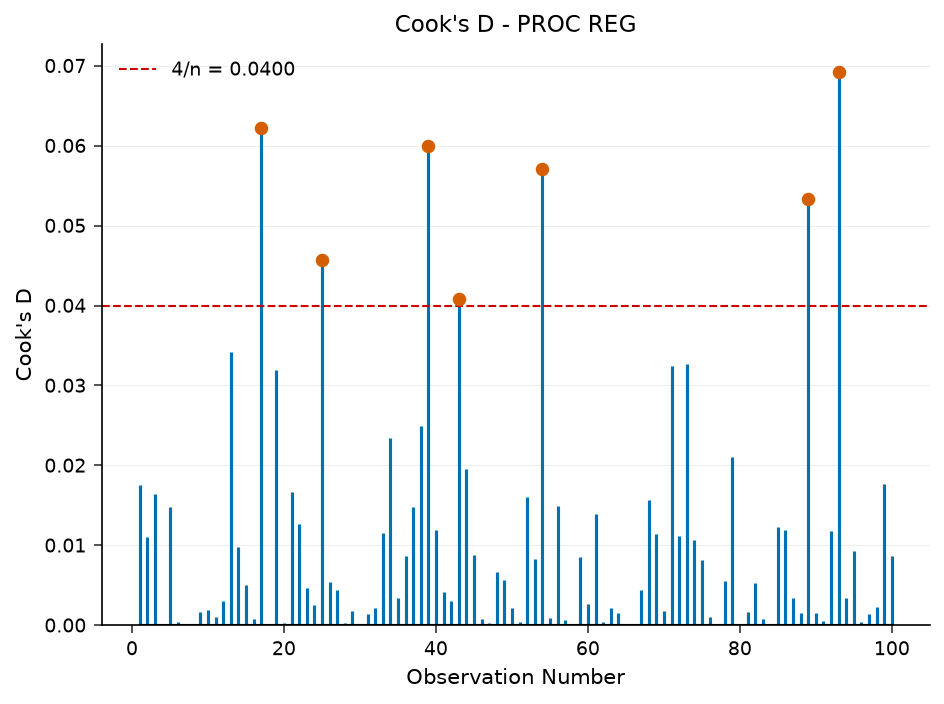

In [13]:
/* --------------------------------------------------------
   Flexible cross-sectional query: top and bottom price
   movers in 2024 with their financing profile.
   -------------------------------------------------------- */
proc sql;
    create table movers_top as
    select metro_name,
           yoy_appreciation,
           origination_count,
           avg_loan_amount,
           denial_rate
    from metro_panel
    where year = (select max(year) from metro_panel)
    order by yoy_appreciation desc;
quit;

title 'Top 5 Appreciating Metros (2024)';
proc print data=movers_top (obs=5) noobs label;
    var metro_name yoy_appreciation origination_count
        avg_loan_amount denial_rate;
    format yoy_appreciation 6.2 origination_count comma10.
           avg_loan_amount dollar12.0 denial_rate 6.2;
run;

proc sort data=movers_top out=movers_bottom;
    by yoy_appreciation;
run;

title 'Bottom 5 Appreciating Metros (2024)';
proc print data=movers_bottom (obs=5) noobs label;
    var metro_name yoy_appreciation origination_count
        avg_loan_amount denial_rate;
    format yoy_appreciation 6.2 origination_count comma10.
           avg_loan_amount dollar12.0 denial_rate 6.2;
run;
title;


In [14]:
/* --------------------------------------------------------
   Formatted market summary: per-metro averages and totals
   across the most recent five years (2020-2024).
   -------------------------------------------------------- */
title 'Metro Housing Market Summary (2020-2024)';
proc report data=metro_panel;
    where year >= 2020;
    column metro_name yoy_appreciation
           annual_permits origination_count;
    define metro_name        / group 'Metro Area';
    define yoy_appreciation  / mean  'Avg YoY HPI (%)'  format=6.2;
    define annual_permits    / sum   'Total Permits'    format=comma12.;
    define origination_count / sum   'Originations'     format=comma12.;
run;
title;


                                        Metro Housing Market Summary (2020-2024)                                        

Metro Area                        Avg YoY HPI (%)  Total Permits  Originations
Atlanta                           2.00             57,443         15,891      
Boston                            5.20             41,343         18,292      
Chicago                           6.00             49,980         22,305      
Dallas                            0.00             63,506         15,335      
Houston                           -0.80            66,528         19,829      
Los Angeles                       9.20             36,363         14,135      
Miami                             2.00             54,440         16,735      
New York                          6.40             40,256         18,403      
Philadelphia                      3.20             43,497         24,340      
Washington                        5.60             39,370         19,640


NOTE: Option TITLE changed to Metro Housing Market Summary (2020-2024).
NOTE: PROC REPORT data=metro_panel

NOTE: PROC REPORT output 10 observations with 4 variables.

NOTE: Read 50 rows from metro_panel.
NOTE: Wrote (console) (10 rows, 4 columns).
NOTE: PROC REPORT elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---
## 5. Results

### Key Findings

> **Finding 1 — Wide dispersion in cumulative appreciation.** Rebased to 2015 = 100, the
> cumulative House Price Index in 2024 ranges from **95.7** (a metro that effectively flat-lined)
> to **289.3** for Los Angeles — a spread of nearly **194 index points**. Supply-constrained
> coastal markets (Los Angeles 289, New York 255, Boston 209) lead, while high-permitting Sun Belt
> metros (Houston 108, Dallas 109, Atlanta 127) sit near or just above their 2015 base.

> **Finding 2 — Permits significantly dampen price growth.** In the OLS model, annual building
> permits are a **statistically significant negative** predictor of year-over-year appreciation
> (**t = -5.52, p < .0001**). The coefficient is tiny in raw per-permit units (it rounds to -0.00 in
> the table), but scaled up it is economically meaningful: each additional **1,000 permits** is
> associated with about **1.4 percentage points** of slower annual price growth. The simple pairwise signal is just
> as strong: PROC CORR reports a permits-appreciation Pearson correlation of **-0.62** (p < .0001),
> the supply-dampening effect predicted by urban-economics theory and visible directly in both the
> correlation heatmap and the downward-sloping scatter. The overall model is significant
> (F = 16.06, p < .0001) and explains **40%** of the variance in appreciation (R-square = 0.40).

> **Finding 3 — Financing variables add little.** The financing metrics are barely correlated with
> appreciation to begin with (originations r = **-0.07**, denial rate r = **+0.12**, both non-significant),
> and in the joint OLS model origination count, average loan amount, and denial rate all remain
> **not** statistically significant (all p > 0.21). VIF values stay below 1.8, so multicollinearity is not
> a concern. After accounting for permitting, the financing profile carries no independent signal in
> this panel.

### Implications

Permit intensity is the dominant, robust signal here: metros that build aggressively cool faster,
while supply-constrained markets compound gains. For portfolio and market analysts, **permit-to-price
trends are a cleaner early-warning indicator than financing metrics** such as denial rates, which
add no independent explanatory power once supply is in the model.

> All figures above are quoted directly from this notebook's executed PROC MEANS, PROC CORR, PROC REG,
> and PROC REPORT output on the synthetic panel; they are illustrative of the modeled relationship,
> not empirical claims about U.S. housing markets.


---
## 6. Export

Write the consolidated metro panel and latest snapshot to CSV for downstream dashboards
and reporting tools.


In [15]:
/* --------------------------------------------------------
   Export the consolidated metro panel and 2024 snapshot.
   -------------------------------------------------------- */
data "results/metro_panel.csv";
    set metro_panel;
run;

data "results/latest_market_snapshot.csv";
    set latest_snapshot;
run;


NOTE: DATA results/metro_panel.csv


NOTE: Read 100 rows from metro_panel.
NOTE: Wrote results/metro_panel.csv (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA results/latest_market_snapshot.csv


NOTE: Read 10 rows from latest_snapshot.
NOTE: Wrote results/latest_market_snapshot.csv (10 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-bottom: 8px;">
&copy; 2026 Jenner Analytics Ltd. All rights reserved. Jenner&trade; is a trademark of Jenner Analytics Ltd.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 11px; line-height: 1.5;">
This notebook is provided for demonstration purposes only. The analysis, data, and findings herein do not constitute real estate, investment, or professional advice. Jenner Analytics Ltd makes no warranties regarding the accuracy or completeness of this content.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-top: 8px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>